In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

# чтение датасета

In [11]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
#поставим когда узнаем варик а так пока свагушка красуется
TEST_SIZE = 0.2
RANDOM_STATE = 67
display(
    train_df,
    test_df
    )



,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
328,500,0.17783,0.0,9.69,0,0.585,5.569,73.5,2.3999,6,391,19.2,395.77,15.10,17.5
329,502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
330,503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
331,504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
1,6,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
2,8,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15
3,9,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93
4,10,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,496,0.17899,0.0,9.69,0,0.585,5.670,28.8,2.7986,6,391,19.2,393.29,17.60
169,497,0.28960,0.0,9.69,0,0.585,5.390,72.9,2.7986,6,391,19.2,396.90,21.14
170,499,0.23912,0.0,9.69,0,0.585,6.019,65.3,2.4091,6,391,19.2,396.90,12.92
171,501,0.22438,0.0,9.69,0,0.585,6.027,79.7,2.4982,6,391,19.2,396.90,14.33


In [12]:
display(
    train_df.describe(),
    train_df.info(),
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       333 non-null    int64  
 1   crim     333 non-null    float64
 2   zn       333 non-null    float64
 3   indus    333 non-null    float64
 4   chas     333 non-null    int64  
 5   nox      333 non-null    float64
 6   rm       333 non-null    float64
 7   age      333 non-null    float64
 8   dis      333 non-null    float64
 9   rad      333 non-null    int64  
 10  tax      333 non-null    int64  
 11  ptratio  333 non-null    float64
 12  black    333 non-null    float64
 13  lstat    333 non-null    float64
 14  medv     333 non-null    float64
dtypes: float64(11), int64(4)
memory usage: 39.2 KB


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,250.951952,3.360341,10.689189,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,359.466096,12.515435,22.768769
std,147.859438,7.352272,22.674762,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,86.584567,7.067781,9.173468
min,1.000000,0.006320,0.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,3.500000,1.730000,5.000000
25%,123.000000,0.078960,0.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,376.730000,7.180000,17.400000
50%,244.000000,0.261690,0.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,392.050000,10.970000,21.600000
75%,377.000000,3.678220,12.500000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,396.240000,16.420000,25.000000
max,506.000000,73.534100,100.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,396.900000,37.970000,50.000000


None

In [13]:
display(
    test_df.describe(),
    test_df.info(),
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       173 non-null    int64  
 1   crim     173 non-null    float64
 2   zn       173 non-null    float64
 3   indus    173 non-null    float64
 4   chas     173 non-null    int64  
 5   nox      173 non-null    float64
 6   rm       173 non-null    float64
 7   age      173 non-null    float64
 8   dis      173 non-null    float64
 9   rad      173 non-null    int64  
 10  tax      173 non-null    int64  
 11  ptratio  173 non-null    float64
 12  black    173 non-null    float64
 13  lstat    173 non-null    float64
dtypes: float64(10), int64(4)
memory usage: 19.1 KB


,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
count,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000,173.000000
mean,258.404624,4.100862,12.661850,10.835145,0.086705,0.549981,6.321237,69.245665,3.958865,9.387283,406.231214,18.469942,351.299711,12.917977
std,143.289788,10.607761,24.536277,6.596488,0.282219,0.117826,0.700621,28.248244,2.324131,8.662621,164.480626,2.196196,99.781464,7.293408
min,3.000000,0.013810,0.000000,0.460000,0.000000,0.392000,4.138000,2.900000,1.178100,1.000000,187.000000,12.600000,0.320000,1.920000
25%,136.000000,0.082210,0.000000,5.320000,0.000000,0.447000,5.895000,42.800000,2.010700,4.000000,279.000000,17.000000,371.720000,6.870000
50%,268.000000,0.251990,0.000000,8.560000,0.000000,0.538000,6.223000,79.200000,3.421100,5.000000,330.000000,19.100000,390.070000,12.120000
75%,381.000000,3.673670,20.000000,18.100000,0.000000,0.624000,6.674000,94.600000,5.400700,24.000000,666.000000,20.200000,396.060000,17.210000
max,505.000000,88.976200,95.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,34.370000


None

In [14]:
# пропуски
print(f'train: {train_df.isnull().sum()}')
print(f'\ntest: {test_df.isnull().sum()}')

train: ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
medv       0
dtype: int64

test: ID         0
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
black      0
lstat      0
dtype: int64


# матрица кореляций и гистограмма расп-ия medv
чтобы понять, что сильнее всего влияет на MEDV

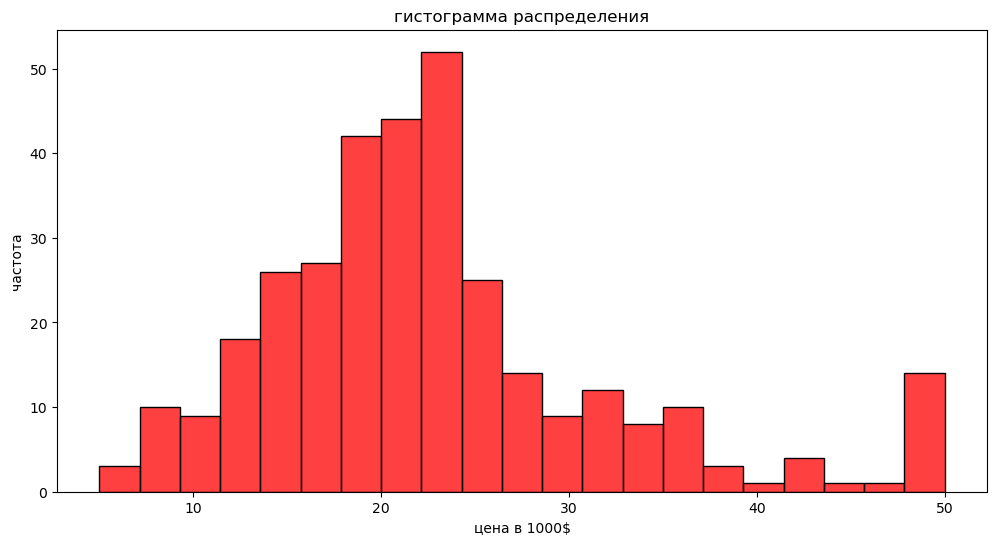

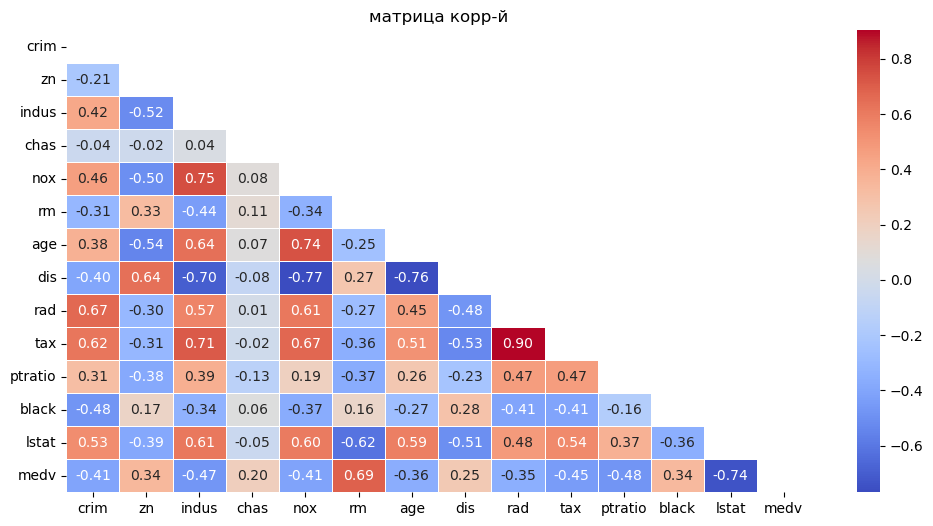

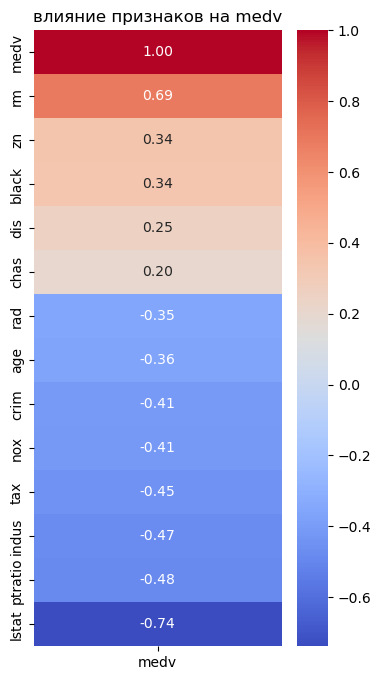

In [15]:
# гистограмма распределения medv
plt.figure(figsize=(12, 6))
sns.histplot(train_df['medv'],  color='red')
plt.xlabel('цена в 1000$')
plt.ylabel('частота')
plt.title('гистограмма распределения')
plt.show()

# матрица корр-й
plt.figure(figsize=(12,  6))
corr_mat = train_df.drop('ID', axis=1).corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, 
            annot=True, 
            mask=mask, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5
)
plt.title('матрица корр-й')
plt.show()

# чтобы проще было делаем один столбец для medv
plt.figure(figsize=(4, 8))
sns.heatmap(corr_mat[['medv']].sort_values(by='medv', ascending=False), 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title('влияние признаков на medv')
plt.show()

In [16]:
train_df.head()

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9


In [17]:
features = train_df.drop(columns=["medv"])
target = train_df.loc[:, ["medv"]]
display(
    features.head(),
    target.head(),
)
X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
3,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
4,7,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43


,medv
0,24.0
1,21.6
2,33.4
3,36.2
4,22.9


In [29]:
scaler = StandardScaler(with_mean=True, with_std=True)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


poly = PolynomialFeatures(degree=2)
X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

In [30]:
model = LinearRegression()
model.fit(X=X_train, y=y_train)

LinearRegression()

In [31]:
y = model.predict(X_test)
res = pd.DataFrame({
    "real": y_test.values.ravel(),
    "predicted": y.ravel(), 
})

In [32]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_pred - y_true))

In [33]:
score = model.score(X_test, y_test)
w = model.coef_
eps = model.intercept_
rank = model.rank_
singulars = model.singular_
mae = mean_absolute_error(y_test, y)

print(f"score={score}")
print(f"weights={w}")
print(f"epsilon={eps}")
print(f"y={y[:20]}")
print(f"rank={rank}")
print(f"mae={mae}")
print(f"singulars={singulars}")


score=0.9075836865656209
weights=[[-3.97468611e-12  5.52569102e-12  7.49934648e-01 -4.70885846e+01
  -4.02135047e+01  1.42131129e+01  8.51264530e-02  3.32457758e-01
   3.59809898e+00 -4.10206248e+00 -2.08069136e+00  1.40346151e+01
  -1.79155057e+01 -2.97074001e+00  6.01778035e-01 -2.42346578e+00
   4.59721150e-12 -1.84208204e-12 -1.21869181e-12 -4.07118783e-13
   8.97948382e-13 -2.47890597e-12 -2.51620946e-12 -2.10631512e-12
  -2.26618724e-12  4.19220214e-13  1.38244971e-12 -1.10667031e-12
  -7.72937270e-13 -5.57554003e-13  1.16484600e-12 -6.67734484e-01
   5.27243123e+00  2.46984881e-01  4.76138793e-01  1.09616193e+00
   2.06032385e-01  1.15596289e+00 -4.99126481e-01 -1.19266423e+00
  -4.11396204e+00 -1.11099842e+00 -8.47404314e-01  3.58045083e-01
   3.35967566e+00  2.82659651e-01 -9.00856057e+01  2.31238638e+01
   1.67551838e+00 -1.35309568e+00  1.05089631e+00 -1.71043595e+00
  -5.80398647e+00  3.26737702e+01 -5.44640522e+01 -1.55591360e+00
  -1.84008753e-02  5.68455414e-01 -3.455737

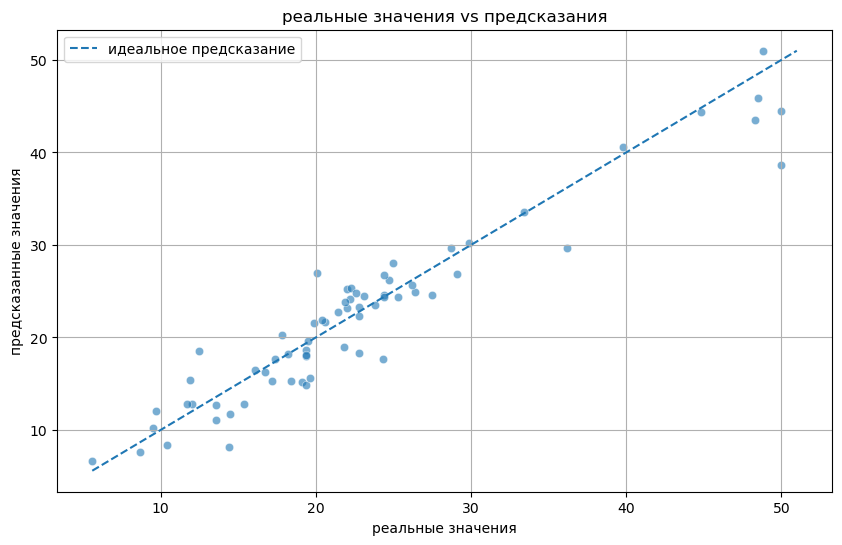

In [34]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=res,
    x="real",
    y="predicted",
    alpha=0.6
)
min_value = min(res["real"].min(), res["predicted"].min())
max_value = max(res["real"].max(), res["predicted"].max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="идеальное предсказание"
)
plt.title("реальные значения vs предсказания")
plt.xlabel("реальные значения")
plt.ylabel("предсказанные значения")
plt.legend()
plt.grid(True)
plt.show()
